# Credit Card Panel Performance Analysis

## Business question

Ocean Finance operates a credit-card marketplace in which applicants may receive multiple card offers, choose whether to click an offer, and may subsequently convert into a completed sale.

The objectives of this analysis is to investigate:

> **Is any individual card harming the overall performance of the credit-card panel - i.e. would the marketplace be better without it? **

## Analytical approach

I will:

1. Understand and validate the data;
2. Establish overall marketplace performance;
3. Compare card-level performance and identify candidates for deeper investigation;
4. Investigate how customers choose between competing offers;
5. Assess whether any underperforming card may be diverting customers from stronger alternatives;
6. Evaluate the uncertainty around removing a card; and
7. Recommend an appropriate business action.

The supplied post-click sales data is aggregated at card level rather than applicant level. Therefore, the true outcome for an individual applicant after clicking cannot be observed directly. Any removal analysis will need to distinguish observed evidence from modelled counterfactual assumptions.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Credit Platform_Analytics Engineer_exercise.xlsx"
)

print("Project root:", PROJECT_ROOT)
print("Workbook found:", DATA_PATH.exists())

Project root: /Users/stavrosrossos/Desktop/ocean_finance_analysis
Workbook found: True


## 1. Understanding the data

Before calculating metrics etc, I first inspect teh workbook structure, table grains and field definitions.

Important because the analysis combines applicant level offer behaviour with card-level post click sales outcomes, and joining data at the wrong grain could produce misleading results.

In [2]:
excel_file = pd.ExcelFile(DATA_PATH)

excel_file.sheet_names

['CreditCardQuoteData', 'Sales Data', 'Definitions']

In [4]:
quote_data = pd.read_excel(
    DATA_PATH,
    sheet_name="CreditCardQuoteData"
)

sales_data = pd.read_excel(
    DATA_PATH,
    sheet_name="Sales Data"
)

definitions = pd.read_excel(
    DATA_PATH,
    sheet_name="Definitions"
)

sheet_summary = pd.DataFrame({
    "sheet": [
        "CreditCardQuoteData",
        "Sales Data",
        "Definitions"
    ],
    "rows": [
        len(quote_data),
        len(sales_data),
        len(definitions)
    ],
    "columns": [
        quote_data.shape[1],
        sales_data.shape[1],
        definitions.shape[1]
    ]
})

sheet_summary

,sheet,rows,columns
0,CreditCardQuoteData,9945,7
1,Sales Data,34,3
2,Definitions,7,2


In [5]:
definitions

,Field,Definition
0,ComparisonApplicationID,ID of Applicant
1,Credit Card ID,ID of Credit Card for which the Applicant has ...
2,ComparisonCardClicked,Flag indicating if Applicant clicked on Credit...
3,ComparisonCardAPR,APR of Credit Card
4,RankComparisonCardAPR,Ranking of Credit Card vs other Credit Card of...
5,ComparisonCardLikelihood,Likelihood score of Credit Card. This roughly ...
6,RankComparisonCardLikelihood,Ranking of Credit Card vs other Credit Card of...


In [6]:
pd.set_option("display.max_colwidth", None)

definitions

,Field,Definition
0,ComparisonApplicationID,ID of Applicant
1,Credit Card ID,ID of Credit Card for which the Applicant has been approved
2,ComparisonCardClicked,Flag indicating if Applicant clicked on Credit Card
3,ComparisonCardAPR,APR of Credit Card
4,RankComparisonCardAPR,Ranking of Credit Card vs other Credit Card offers the given Applicant has been approved for - by APR (lowest = best = 1)
5,ComparisonCardLikelihood,"Likelihood score of Credit Card. This roughly represents the probability that the Applicant will actually get the Card (resulting in a Sale and hence generating commission) if they click on their offer and follow the Lender's process to the end. This is displayed to the customer on the results page, alongside the APR (among other)."
6,RankComparisonCardLikelihood,"Ranking of Credit Card vs other Credit Card offers the given Applicant has been approved for - by Likelihood score (highest = best = 1). Notably, Applicants see their Credit Card offers (i.e. the cards they have been approved for) in this order."


### Data structure and implications

The workbook contains three sheets:

- **CreditCardQuoteData** - 9,945 rows and 7 columns
- **Sales Data** - 34 rows and 3 columnns
- **Definitions** - field-level metadata

The quote data appears to be at **application x card offer grain**: an applicant may receive multiple approved card offers, with each row representing one card.

The sales data appears to be at **card grain**, containing aggregated post click sales and revenue by card rather than individual applicant outcomes.

Two customer-facing variables are especially important for later analysis:

- **APR rank:** lower APR is better, with rank 1 representing the lowest APR available to that applicant.
- **Likelihood rank:** higher likelihood is better, with rank 1 representing the highest likelihood score. The definitions state that offers are shown to applicants in this likelihood-ranked order.

The likelihood score only roughly represents the probability of ultimately receiving the card after clickout. I will therefore treat it as an informative customer-facing score and ranking variable rather than assume that it is a perfectly calibrated conversion probability.

A key limitation is that individual clicks cannot be linked directly to individual sales because post-click outcomes are only supplied in aggregate by card. This limits causal claims about what would happen if a card were removed.

In [7]:
display(quote_data.head())
display(sales_data.head())

print("Quote data types:")
display(quote_data.dtypes.to_frame("dtype"))

print("Sales data types:")
display(sales_data.dtypes.to_frame("dtype"))

,ComparisonApplicationID,Credit Card ID,ComparisonCardClicked,ComparisonCardAPR,RankComparisonCardAPR,ComparisonCardLikelihood,RankComparisonCardLikelihood
0,Uk9ZcElEY1hYelM0eEo3amJES0Qvdz090,Card 1,0,21.9,1,90,1
1,R0tOTDJmdU1Mai9DOHZwQjNvdzR5Zz090,Card 2,1,29.3,1,100,1
2,R0tOTDJmdU1Mai9DOHZwQjNvdzR5Zz090,Card 3,0,29.3,1,100,1
3,akZoM0NGc0hDK0xPcC9rU2FUaUVRZz090,Card 4,0,34.7,1,100,1
4,M2pZcHBUbTZwd2ttQklOaVpBOHRjZz090,Card 7,1,29.9,1,100,1


,Card ID,Sales,Revenue
0,Card 8,33,1485.0
1,Card 10,22,990.0
2,Card 30,89,3916.0
3,Card 29,63,2772.0
4,Card 6,1,35.0


Quote data types:


,dtype
ComparisonApplicationID,str
Credit Card ID,str
ComparisonCardClicked,int64
ComparisonCardAPR,float64
RankComparisonCardAPR,int64
ComparisonCardLikelihood,int64
RankComparisonCardLikelihood,int64


Sales data types:


,dtype
Card ID,str
Sales,int64
Revenue,float64


In [8]:
data_quality_summary = pd.DataFrame({
    "metric": [
        "Quote rows",
        "Unique applications",
        "Unique cards in quote data",
        "Sales rows",
        "Unique cards in sales data",
        "Duplicate application-card rows",
        "Missing values in quote data",
        "Missing values in sales data",
    ],
    "value": [
        len(quote_data),
        quote_data["ComparisonApplicationID"].nunique(),
        quote_data["Credit Card ID"].nunique(),
        len(sales_data),
        sales_data["Card ID"].nunique(),
        quote_data.duplicated(
            subset=["ComparisonApplicationID", "Credit Card ID"]
        ).sum(),
        quote_data.isna().sum().sum(),
        sales_data.isna().sum().sum(),
    ]
})

data_quality_summary

,metric,value
0,Quote rows,9945
1,Unique applications,3684
2,Unique cards in quote data,34
3,Sales rows,34
4,Unique cards in sales data,34
5,Duplicate application-card rows,0
6,Missing values in quote data,0
7,Missing values in sales data,0


### Data quality checks

The supplied data is structurally clean:

- 9,945 card-offer rows across 3,684 applications;
- 34 unique cards in the quote data and 34 rows in the sales data;
- no duplicated application-card combinations;
- no missing values in either analytical dataset.

This supports treating the quote data as one row per **application × card offer** and the sales data as one row per **card**.

Before calculating performance metrics, I next checked whether the two datasets cover the same cards and whether key fields such as click flags and ranking variables behave as expected.

In [9]:
quote_cards = set(quote_data["Credit Card ID"].unique())
sales_cards = set(sales_data["Card ID"].unique())

validation_summary = pd.DataFrame({
    "metric": [
        "Cards in quote data but not sales data",
        "Cards in sales data but not quote data",
        "Observed click flag values",
        "Minimum APR",
        "Maximum APR",
        "Minimum likelihood",
        "Maximum likelihood",
        "Minimum APR rank",
        "Maximum APR rank",
        "Minimum likelihood rank",
        "Maximum likelihood rank",
    ],
    "value": [
        str(quote_cards - sales_cards),
        str(sales_cards - quote_cards),
        str(sorted(quote_data["ComparisonCardClicked"].unique())),
        quote_data["ComparisonCardAPR"].min(),
        quote_data["ComparisonCardAPR"].max(),
        quote_data["ComparisonCardLikelihood"].min(),
        quote_data["ComparisonCardLikelihood"].max(),
        quote_data["RankComparisonCardAPR"].min(),
        quote_data["RankComparisonCardAPR"].max(),
        quote_data["RankComparisonCardLikelihood"].min(),
        quote_data["RankComparisonCardLikelihood"].max(),
    ]
})

validation_summary

,metric,value
0,Cards in quote data but not sales data,set()
1,Cards in sales data but not quote data,set()
2,Observed click flag values,"[np.int64(0), np.int64(1)]"
3,Minimum APR,12.9
4,Maximum APR,59.9
5,Minimum likelihood,50
6,Maximum likelihood,100
7,Minimum APR rank,1
8,Maximum APR rank,17
9,Minimum likelihood rank,1


In [10]:
rank_checks = (
    quote_data
    .groupby("ComparisonApplicationID")
    .apply(
        lambda group: pd.Series({
            "apr_rank_1_is_lowest_apr":
                group.loc[
                    group["RankComparisonCardAPR"] == 1,
                    "ComparisonCardAPR"
                ].min()
                == group["ComparisonCardAPR"].min(),

            "likelihood_rank_1_is_highest_likelihood":
                group.loc[
                    group["RankComparisonCardLikelihood"] == 1,
                    "ComparisonCardLikelihood"
                ].max()
                == group["ComparisonCardLikelihood"].max()
        }),
        include_groups=False
    )
)

rank_checks.mean()

apr_rank_1_is_lowest_apr                   1.0
likelihood_rank_1_is_highest_likelihood    1.0
dtype: float64

## 2. Application-level behaviour

The quote table is at offer level, so an applicant can appear on multiple rows.

Before analysing individual card performance, I aggregated the data to one row per
application to understand:

- how many offers applicants typically receive;
- how frequently applicants click;
- whether applicants ever click more than one offer.

This establishes the overall customer journey and identifies any behaviour that
could affect later card-level analysis.

In [11]:
application_summary = (
    quote_data
    .groupby("ComparisonApplicationID")
    .agg(
        offers_received=("Credit Card ID", "count"),
        cards_clicked=("ComparisonCardClicked", "sum"),
    )
    .reset_index()
)

application_summary["made_click"] = (
    application_summary["cards_clicked"] > 0
)

application_summary.head()

,ComparisonApplicationID,offers_received,cards_clicked,made_click
0,K043Y1JZNTExb0ZjUkh6K1BCTEE3dz090,5,0,False
1,K053bWNzZCtIQkVpVVFCZlJtZHhQZz090,1,0,False
2,K05nbTJtS1RGZ1VId0UyTERoMlJSZz090,3,1,True
3,K091c2xITXQ1VE1lMXYzMEx2c3gwZz090,1,0,False
4,K09WWVZiQXFnaHN6eVJ3OUtTMFBBQT090,2,1,True


In [12]:
offer_summary = (
    application_summary["offers_received"]
    .describe()
    .to_frame("offers_received")
)

click_distribution = (
    application_summary["cards_clicked"]
    .value_counts()
    .sort_index()
    .rename_axis("cards_clicked")
    .reset_index(name="applications")
)

display(offer_summary)
display(click_distribution)

,offers_received
count,3684.000000
mean,2.699511
std,2.165709
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,17.000000


,cards_clicked,applications
0,0,1843
1,1,1821
2,2,18
3,3,2


In [13]:
application_behavior_summary = pd.DataFrame({
    "metric": [
        "Applications",
        "Average offers per application",
        "Median offers per application",
        "Minimum offers",
        "Maximum offers",
        "Applications with at least one click",
        "Application clickout rate",
        "Multi-click applications",
        "Multi-click application rate",
    ],
    "value": [
        len(application_summary),
        application_summary["offers_received"].mean(),
        application_summary["offers_received"].median(),
        application_summary["offers_received"].min(),
        application_summary["offers_received"].max(),
        application_summary["made_click"].sum(),
        application_summary["made_click"].mean(),
        (application_summary["cards_clicked"] > 1).sum(),
        (application_summary["cards_clicked"] > 1).mean(),
    ]
})

application_behavior_summary

,metric,value
0,Applications,3684.000000
1,Average offers per application,2.699511
2,Median offers per application,2.000000
3,Minimum offers,1.000000
4,Maximum offers,17.000000
5,Applications with at least one click,1841.000000
6,Application clickout rate,0.499729
7,Multi-click applications,20.000000
8,Multi-click application rate,0.005429


### Application-level findings

Applicants receive a median of **2 card offers** and an average of **2.7**, although the number of available offers ranges from 1 to 17.

Of the 3,684 applications:

- **1,841 (50.0%)** clicked at least one card;
- **1,843 (50.0%)** did not click any card;
- only **20 applications (0.54%)** clicked more than one card.

Multi-click behaviour therefore exists, but it is rare. I will retain these applications rather than remove valid observed behaviour, while avoiding later assumptions that every application contains exactly one click.

The roughly 50% application clickout rate also provides an important panel-level baseline: removing a card could improve downstream conversion while still harming the marketplace if it causes more applicants to click nothing.

## 3. Marketplace baseline

Before identifying potentially harmful cards, I established the overall marketplace funnel.

The key stages available in the supplied data are:

**Applications → card offers → clickouts → sales → revenue**

Because applicants may receive multiple offers, offer-level click-through rate and application-level clickout rate answer different questions and should not be confused.

In [15]:
total_applications = quote_data["ComparisonApplicationID"].nunique()
total_offers = len(quote_data)
total_clicks = quote_data["ComparisonCardClicked"].sum()

total_sales = sales_data["Sales"].sum()
total_revenue = sales_data["Revenue"].sum()

applications_with_click = application_summary["made_click"].sum()

panel_metrics = pd.DataFrame({
    "metric": [
        "Applications",
        "Card offers",
        "Applications with a click",
        "Total clickouts",
        "Sales",
        "Revenue",
        "Application clickout rate",
        "Offer click-through rate",
        "Click-to-sale conversion",
        "Revenue per application",
        "Revenue per click",
        "Sales per 100 applications",
    ],
    "value": [
        total_applications,
        total_offers,
        applications_with_click,
        total_clicks,
        total_sales,
        total_revenue,
        applications_with_click / total_applications,
        total_clicks / total_offers,
        total_sales / total_clicks,
        total_revenue / total_applications,
        total_revenue / total_clicks,
        total_sales / total_applications * 100,
    ]
})

panel_metrics

,metric,value
0,Applications,3684.000000
1,Card offers,9945.000000
2,Applications with a click,1841.000000
3,Total clickouts,1863.000000
4,Sales,555.000000
5,Revenue,21087.860000
6,Application clickout rate,0.499729
7,Offer click-through rate,0.187330
8,Click-to-sale conversion,0.297907
9,Revenue per application,5.724175


### Marketplace baseline findings

Across the observed period, the marketplace processed **3,684 applications** and returned **9,945 card offers**.

At application level, **50.0% of applicants clicked at least one card**. At offer level, the click-through rate was **18.7%**, reflecting the fact that applicants can receive multiple offers.

Downstream, the panel generated:

- **555 sales**
- **£21,087.86 revenue**
- **29.8% click-to-sale conversion**
- **£11.32 revenue per click**
- **£5.72 revenue per application**
- **15.1 sales per 100 applications**

These provide the baseline against which individual cards should be assessed.

For the question of whether a card is harming the panel, I am particularly interested in cards that combine **meaningful click volume** with **weak downstream monetisation**. A card with poor conversion but negligible traffic is unlikely to materially affect overall marketplace performance.

## 4. Card-level performance screening

I first compared card-level traffic and downstream commercial performance.

Rather than ranking cards only by conversion rate, I considered both:

- **volume** — how often a card is offered and clicked;
- **monetisation** — sales, revenue, conversion and revenue per click.

This helps distinguish low-volume weak cards from cards that could materially affect total panel performance.

In [16]:
quote_card_metrics = (
    quote_data
    .groupby("Credit Card ID")
    .agg(
        offers=("ComparisonApplicationID", "count"),
        clicks=("ComparisonCardClicked", "sum"),
        avg_apr=("ComparisonCardAPR", "mean"),
        avg_likelihood=("ComparisonCardLikelihood", "mean"),
        avg_apr_rank=("RankComparisonCardAPR", "mean"),
        avg_likelihood_rank=("RankComparisonCardLikelihood", "mean"),
    )
    .reset_index()
)

card_performance = (
    quote_card_metrics
    .merge(
        sales_data,
        left_on="Credit Card ID",
        right_on="Card ID",
        how="left"
    )
)

card_performance["click_through_rate"] = (
    card_performance["clicks"]
    / card_performance["offers"]
)

card_performance["click_to_sale_rate"] = (
    card_performance["Sales"]
    / card_performance["clicks"]
)

card_performance["revenue_per_click"] = (
    card_performance["Revenue"]
    / card_performance["clicks"]
)

card_performance["revenue_per_offer"] = (
    card_performance["Revenue"]
    / card_performance["offers"]
)

card_performance["revenue_per_sale"] = (
    card_performance["Revenue"]
    / card_performance["Sales"]
)

card_performance = (
    card_performance
    .sort_values("clicks", ascending=False)
)

card_performance[
    [
        "Credit Card ID",
        "offers",
        "clicks",
        "click_through_rate",
        "Sales",
        "click_to_sale_rate",
        "Revenue",
        "revenue_per_click",
        "revenue_per_sale",
    ]
].head(15)

,Credit Card ID,offers,clicks,click_through_rate,Sales,click_to_sale_rate,Revenue,revenue_per_click,revenue_per_sale
21,Card 29,1596,398,0.249373,63,0.158291,2772.0,6.964824,44.0
23,Card 30,1600,281,0.175625,89,0.316726,3916.0,13.935943,44.0
31,Card 7,487,185,0.379877,65,0.351351,2210.0,11.945946,34.0
33,Card 9,445,122,0.274157,43,0.352459,1462.0,11.983607,34.0
15,Card 23,300,92,0.306667,30,0.326087,1050.0,11.413043,35.0
28,Card 4,218,84,0.385321,30,0.357143,1020.0,12.142857,34.0
24,Card 31,1458,80,0.054870,21,0.262500,924.0,11.550000,44.0
16,Card 24,183,76,0.415301,25,0.328947,875.0,11.513158,35.0
32,Card 8,269,75,0.278810,33,0.440000,1485.0,19.800000,45.0
11,Card 2,229,65,0.283843,31,0.476923,1085.0,16.692308,35.0


### Initial screening finding

Card 29 stands out as the clearest high-impact underperformer.

It receives **398 clicks — the highest volume in the panel — but converts only
15.8% of those clicks into sales and generates £6.96 revenue per click**, well
below the panel average of £11.32.

This is more commercially concerning than cards with poor conversion but little
customer traffic, because Card 29 has enough volume to materially affect overall
panel performance.

Card 30 also provides a potentially useful comparison: it is offered at almost
the same scale, generates the same £44 revenue per sale, but converts at 31.7%
and produces £13.94 revenue per click.

I therefore investigated whether Card 29 is simply a weak card, or whether its
presence may be diverting customer clicks from stronger alternatives.

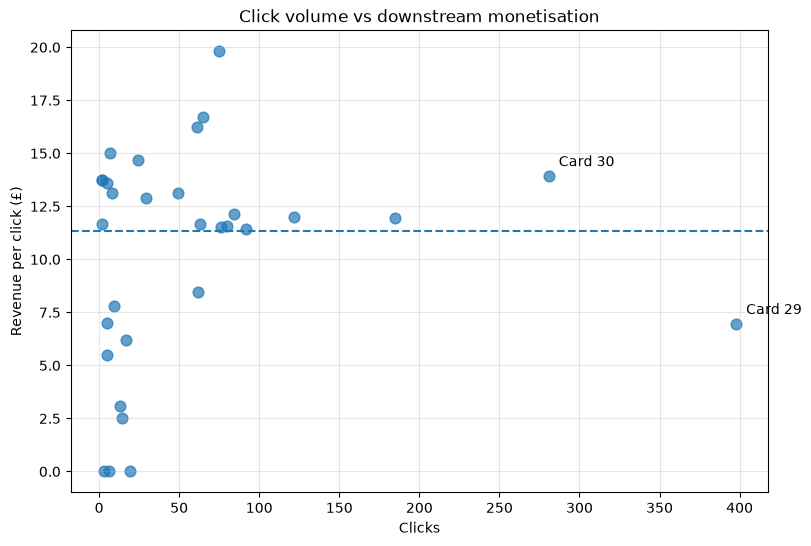

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    card_performance["clicks"],
    card_performance["revenue_per_click"],
    s=60,
    alpha=0.7
)

ax.axhline(
    total_revenue / total_clicks,
    linestyle="--",
    linewidth=1.5
)

for card in ["Card 29", "Card 30"]:
    row = card_performance[
        card_performance["Credit Card ID"] == card
    ].iloc[0]

    ax.annotate(
        card,
        (
            row["clicks"],
            row["revenue_per_click"]
        ),
        xytext=(7, 7),
        textcoords="offset points"
    )

ax.set_xlabel("Clicks")
ax.set_ylabel("Revenue per click (£)")
ax.set_title("Click volume vs downstream monetisation")

ax.grid(True, alpha=0.3)

plt.show()

### Visual screening

The scatter plot confirms that Card 29 is unusual across the full panel.

It has the highest click volume by a wide margin, while its revenue per click
is substantially below the panel average. Most other weakly monetising cards
have relatively little traffic and therefore less potential to affect overall
marketplace performance.

Card 30 is also notable because it operates at similarly high volume but
generates materially more revenue per click.

This suggests that the next question is not simply whether Card 29 performs
poorly, but **why customers are choosing it so frequently**.

## 5. What appears to drive customer clicks?

Applicants see both APR and likelihood information, and offers are ordered by
likelihood rank.

I therefore first examined whether click behaviour varies systematically with:

- likelihood rank; and
- APR rank.

This provides context for understanding why particular cards may attract
disproportionate customer attention.

In [18]:
clicks_by_likelihood_rank = (
    quote_data
    .groupby("RankComparisonCardLikelihood")
    .agg(
        offers=("ComparisonApplicationID", "count"),
        clicks=("ComparisonCardClicked", "sum"),
    )
    .reset_index()
)

clicks_by_likelihood_rank["click_through_rate"] = (
    clicks_by_likelihood_rank["clicks"]
    / clicks_by_likelihood_rank["offers"]
)

clicks_by_likelihood_rank

,RankComparisonCardLikelihood,offers,clicks,click_through_rate
0,1,6321,1627,0.257396
1,2,1263,139,0.110055
2,3,915,61,0.066667
3,4,614,22,0.035831
4,5,300,8,0.026667
5,6,193,4,0.020725
6,7,76,0,0.000000
7,8,72,1,0.013889
8,9,59,1,0.016949
9,10,49,0,0.000000


In [19]:
clicks_by_apr_rank = (
    quote_data
    .groupby("RankComparisonCardAPR")
    .agg(
        offers=("ComparisonApplicationID", "count"),
        clicks=("ComparisonCardClicked", "sum"),
    )
    .reset_index()
)

clicks_by_apr_rank["click_through_rate"] = (
    clicks_by_apr_rank["clicks"]
    / clicks_by_apr_rank["offers"]
)

clicks_by_apr_rank

,RankComparisonCardAPR,offers,clicks,click_through_rate
0,1,4334,1425,0.328796
1,2,2731,238,0.087148
2,3,826,69,0.083535
3,4,792,97,0.122475
4,5,423,8,0.018913
5,6,258,11,0.042636
6,7,168,3,0.017857
7,8,133,5,0.037594
8,9,80,3,0.037500
9,10,77,2,0.025974


### Click behaviour findings

Customer clicks are strongly concentrated among the most attractive offers.

Offers with **likelihood rank 1** have a 25.7% click-through rate, falling sharply
to 11.0% at rank 2 and 6.7% at rank 3.

APR shows a similar pattern: offers with the **lowest APR (rank 1)** have a 32.9%
click-through rate, compared with 8.7% at rank 2.

This suggests that both **display prominence / likelihood** and **APR
attractiveness** are associated with customer choice.

However, these relationships should not be interpreted causally. Rank values can
also be tied within an application, and card identity and offer combinations may
influence behaviour. I therefore next examined which cards are commonly offered
together with Card 29.

In [20]:
pairs = quote_data[
    ["ComparisonApplicationID", "Credit Card ID"]
].merge(
    quote_data[
        ["ComparisonApplicationID", "Credit Card ID"]
    ],
    on="ComparisonApplicationID",
    suffixes=("_a", "_b")
)

pairs = pairs[
    pairs["Credit Card ID_a"] < pairs["Credit Card ID_b"]
]

card_pairs = (
    pairs
    .groupby(
        ["Credit Card ID_a", "Credit Card ID_b"]
    )
    .size()
    .reset_index(name="applications_together")
    .sort_values(
        "applications_together",
        ascending=False
    )
)

card_pairs.head(20)

,Credit Card ID_a,Credit Card ID_b,applications_together
421,Card 30,Card 31,1337
403,Card 29,Card 31,1278
402,Card 29,Card 30,1251
280,Card 2,Card 3,213
412,Card 29,Card 9,183
157,Card 14,Card 29,173
410,Card 29,Card 7,170
464,Card 5,Card 6,168
428,Card 30,Card 7,163
158,Card 14,Card 30,163


In [21]:
card29_pairs = card_pairs[
    (card_pairs["Credit Card ID_a"] == "Card 29")
    | (card_pairs["Credit Card ID_b"] == "Card 29")
].copy()

card29_pairs["other_card"] = np.where(
    card29_pairs["Credit Card ID_a"] == "Card 29",
    card29_pairs["Credit Card ID_b"],
    card29_pairs["Credit Card ID_a"]
)

card29_pairs[
    ["other_card", "applications_together"]
].sort_values(
    "applications_together",
    ascending=False
).head(15)

,other_card,applications_together
403,Card 31,1278
402,Card 30,1251
412,Card 9,183
157,Card 14,173
410,Card 7,170
352,Card 25,125
279,Card 2,120
401,Card 3,119
411,Card 8,115
409,Card 6,105


### Card 29's competitive context

Card 29 is most frequently shown alongside **Card 31 (1,278 applications)**
and **Card 30 (1,251 applications)**. Co-occurrence with every other card is
substantially lower.

I therefore compared Card 29 with these two high-volume alternatives within the
same applications. A within-application comparison is more informative than
comparing aggregate card averages alone because the applicant had both offers
available at the same time.

In [22]:
def compare_card_pair(data, card_a, card_b):

    pair_data = data[
        data["Credit Card ID"].isin([card_a, card_b])
    ].copy()

    # Keep only applications where both cards were offered
    pair_counts = (
        pair_data
        .groupby("ComparisonApplicationID")["Credit Card ID"]
        .nunique()
    )

    eligible_applications = pair_counts[
        pair_counts == 2
    ].index

    pair_data = pair_data[
        pair_data["ComparisonApplicationID"].isin(
            eligible_applications
        )
    ]

    wide = pair_data.pivot(
        index="ComparisonApplicationID",
        columns="Credit Card ID",
        values=[
            "ComparisonCardClicked",
            "ComparisonCardAPR",
            "ComparisonCardLikelihood",
            "RankComparisonCardAPR",
            "RankComparisonCardLikelihood",
        ]
    )

    summary = {
        "comparison_card": card_b,
        "applications_together": len(wide),

        "card29_click_rate":
            wide["ComparisonCardClicked"][card_a].mean(),

        "comparison_card_click_rate":
            wide["ComparisonCardClicked"][card_b].mean(),

        "same_likelihood_rate":
            (
                wide["ComparisonCardLikelihood"][card_a]
                == wide["ComparisonCardLikelihood"][card_b]
            ).mean(),

        "card29_lower_apr_rate":
            (
                wide["ComparisonCardAPR"][card_a]
                < wide["ComparisonCardAPR"][card_b]
            ).mean(),

        "card29_higher_likelihood_rate":
            (
                wide["ComparisonCardLikelihood"][card_a]
                > wide["ComparisonCardLikelihood"][card_b]
            ).mean(),
    }

    return summary

In [23]:
card29_pair_comparisons = pd.DataFrame([
    compare_card_pair(
        quote_data,
        "Card 29",
        "Card 30"
    ),
    compare_card_pair(
        quote_data,
        "Card 29",
        "Card 31"
    ),
])

card29_pair_comparisons

,comparison_card,applications_together,card29_click_rate,comparison_card_click_rate,same_likelihood_rate,card29_lower_apr_rate,card29_higher_likelihood_rate
0,Card 30,1251,0.212630,0.089528,0.972022,1.0,0.027978
1,Card 31,1278,0.214397,0.044601,0.838811,1.0,0.161189


### Within-application comparison

Card 29 appears highly competitive at the point of customer choice.

When shown with Card 30, Card 29 has the lower APR in every observed application
and the same likelihood score in 97.2% of cases. When shown with Card 31, it again
has the lower APR in every case and the same likelihood score in 83.9% of cases.

Where likelihood differs, Card 29 has the higher likelihood rather than the lower
one.

Consistent with these customer-facing advantages, Card 29 attracts substantially
more clicks than either of its two main competing offers.

The next question is therefore whether this stronger click capture translates
into equally strong downstream commercial performance.

In [24]:
card29_pair_comparisons["click_rate_multiple"] = (
    card29_pair_comparisons["card29_click_rate"]
    / card29_pair_comparisons["comparison_card_click_rate"]
)

card29_pair_comparisons[
    [
        "comparison_card",
        "applications_together",
        "card29_click_rate",
        "comparison_card_click_rate",
        "click_rate_multiple",
        "same_likelihood_rate",
        "card29_lower_apr_rate",
    ]
]

,comparison_card,applications_together,card29_click_rate,comparison_card_click_rate,click_rate_multiple,same_likelihood_rate,card29_lower_apr_rate
0,Card 30,1251,0.212630,0.089528,2.375000,0.972022,1.0
1,Card 31,1278,0.214397,0.044601,4.807018,0.838811,1.0


In [25]:
main_competitors = card_performance[
    card_performance["Credit Card ID"].isin(
        ["Card 29", "Card 30", "Card 31"]
    )
][
    [
        "Credit Card ID",
        "offers",
        "clicks",
        "Sales",
        "click_to_sale_rate",
        "Revenue",
        "revenue_per_click",
        "revenue_per_sale",
        "avg_apr",
        "avg_likelihood",
    ]
].copy()

main_competitors

,Credit Card ID,offers,clicks,Sales,click_to_sale_rate,Revenue,revenue_per_click,revenue_per_sale,avg_apr,avg_likelihood
21,Card 29,1596,398,63,0.158291,2772.0,6.964824,44.0,29.9,94.116541
23,Card 30,1600,281,89,0.316726,3916.0,13.935943,44.0,32.9,93.087500
24,Card 31,1458,80,21,0.262500,924.0,11.550000,44.0,32.9,92.880658


### Customer attraction does not translate into downstream performance

Card 29 wins substantially more customer attention than either of its two main
competitors:

- **2.38× the click rate of Card 30** when both are shown;
- **4.81× the click rate of Card 31** when both are shown.

However, its downstream performance is materially weaker.

Card 29 converts only **15.8%** of clicks into sales, compared with **31.7% for
Card 30** and **26.3% for Card 31**. It consequently generates only **£6.96 per
click**, versus £13.94 and £11.55 respectively.

All three cards generate **£44 per completed sale**, so Card 29's weaker
monetisation is driven by its lower observed post-click conversion rather than
a lower commission value.

This creates a potential cannibalisation concern: Card 29 appears particularly
attractive on the marketplace and captures disproportionate click volume, but
those clicks produce weaker downstream outcomes than clicks on its main
alternatives.

## 6. Is Card 29's conversion gap statistically meaningful?

The observed conversion rates differ substantially, but the cards also have
different click volumes.

I therefore calculated 95% confidence intervals around each observed
click-to-sale conversion rate and tested Card 29 against its two principal
competitors.

These tests assess whether the observed rate differences are consistent with
sampling variation; they do **not** establish that card identity itself causes
the difference, since applicant-level sales outcomes are unavailable.

In [27]:
from statsmodels.stats.proportion import (
    proportion_confint,
    proportions_ztest
)

In [28]:
comparison_cards = main_competitors[
    ["Credit Card ID", "clicks", "Sales"]
].copy()

ci_results = []

for _, row in comparison_cards.iterrows():

    lower, upper = proportion_confint(
        count=int(row["Sales"]),
        nobs=int(row["clicks"]),
        alpha=0.05,
        method="wilson"
    )

    ci_results.append({
        "card": row["Credit Card ID"],
        "clicks": int(row["clicks"]),
        "sales": int(row["Sales"]),
        "conversion_rate": row["Sales"] / row["clicks"],
        "ci_lower": lower,
        "ci_upper": upper,
    })

conversion_uncertainty = pd.DataFrame(ci_results)

conversion_uncertainty

,card,clicks,sales,conversion_rate,ci_lower,ci_upper
0,Card 29,398,63,0.158291,0.125720,0.197396
1,Card 30,281,89,0.316726,0.265117,0.373278
2,Card 31,80,21,0.262500,0.178574,0.368190


In [29]:
tests = []

card29 = main_competitors[
    main_competitors["Credit Card ID"] == "Card 29"
].iloc[0]

for comparison_card in ["Card 30", "Card 31"]:

    other = main_competitors[
        main_competitors["Credit Card ID"] == comparison_card
    ].iloc[0]

    z_stat, p_value = proportions_ztest(
        count=[
            int(card29["Sales"]),
            int(other["Sales"])
        ],
        nobs=[
            int(card29["clicks"]),
            int(other["clicks"])
        ]
    )

    tests.append({
        "comparison": f"Card 29 vs {comparison_card}",
        "conversion_difference_pp": (
            card29["click_to_sale_rate"]
            - other["click_to_sale_rate"]
        ) * 100,
        "z_statistic": z_stat,
        "p_value": p_value,
    })

conversion_tests = pd.DataFrame(tests)

conversion_tests

,comparison,conversion_difference_pp,z_statistic,p_value
0,Card 29 vs Card 30,-15.843452,-4.878118,0.000001
1,Card 29 vs Card 31,-10.420854,-2.234684,0.025438


### Conversion-rate uncertainty

Card 29's weaker observed conversion is unlikely to be explained by sampling
variation alone.

Its click-to-sale conversion is **15.8% (95% CI: 12.6%–19.7%)**, compared with:

- **31.7% (26.5%–37.3%) for Card 30**
- **26.3% (17.9%–36.8%) for Card 31**

The difference against Card 30 is particularly strong
(two-proportion test, p < 0.001). The difference against Card 31 is smaller
but remains statistically significant at the 5% level (p = 0.025).

These tests strengthen the evidence that Card 29 is a genuine downstream
underperformer. They do not establish causality: sales outcomes are supplied
only at aggregate card level, so differences in the applicants selecting each
card cannot be controlled for directly.

## 7. Do Card 29 clickers have alternative offers?

Poor performance alone does not imply that removing a card would improve the
panel.

If Card 29 were removed, some customers might choose another card, while others
might click nothing. The first step is therefore to determine how many Card 29
clickers actually had alternative offers available in their observed result set.

In [30]:
card29_clicker_ids = quote_data.loc[
    (quote_data["Credit Card ID"] == "Card 29")
    & (quote_data["ComparisonCardClicked"] == 1),
    "ComparisonApplicationID"
].unique()

card29_clickers = quote_data[
    quote_data["ComparisonApplicationID"].isin(card29_clicker_ids)
].copy()

alternative_counts = (
    card29_clickers[
        card29_clickers["Credit Card ID"] != "Card 29"
    ]
    .groupby("ComparisonApplicationID")
    .size()
    .reindex(card29_clicker_ids, fill_value=0)
)

alternative_availability = pd.DataFrame({
    "metric": [
        "Card 29 clickers",
        "Clickers with at least one alternative",
        "Clickers with no alternative",
        "Share with at least one alternative",
        "Average number of alternatives",
    ],
    "value": [
        len(card29_clicker_ids),
        (alternative_counts > 0).sum(),
        (alternative_counts == 0).sum(),
        (alternative_counts > 0).mean(),
        alternative_counts.mean(),
    ]
})

alternative_availability

,metric,value
0,Card 29 clickers,398.000000
1,Clickers with at least one alternative,315.000000
2,Clickers with no alternative,83.000000
3,Share with at least one alternative,0.791457
4,Average number of alternatives,1.804020


In [31]:
available_alternatives = (
    card29_clickers[
        card29_clickers["Credit Card ID"] != "Card 29"
    ]
    .groupby("Credit Card ID")
    .agg(
        card29_clickers_with_card=(
            "ComparisonApplicationID",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "card29_clickers_with_card",
        ascending=False
    )
)

available_alternatives.head(15)

,Credit Card ID,card29_clickers_with_card
18,Card 31,274
17,Card 30,266
5,Card 14,25
22,Card 7,17
6,Card 15,15
12,Card 23,14
24,Card 9,13
14,Card 25,10
1,Card 10,9
7,Card 16,8


### Alternative availability

Most Card 29 clickers had another offer available, but not all.

Of the **398 applicants who clicked Card 29**:

- **315 (79.1%)** had at least one alternative card available;
- **83 (20.9%)** had no alternative offer in their observed panel.

Cards 30 and 31 were by far the most commonly available alternatives, appearing
for 266 and 274 Card 29 clickers respectively.

This means removal could plausibly redirect a meaningful share of Card 29 traffic,
but full substitution should not be assumed. Some applicants would have no
alternative available, while others might still choose not to click a replacement.

## 8. Modelled replacement opportunity

The data does not show what an applicant would have clicked if Card 29 had not
been present.

I therefore constructed a simple counterfactual proxy for each Card 29 clicker
with at least one alternative offer.

After removing Card 29, the model selects the available card with:

1. the best likelihood rank;
2. the lowest APR where likelihood rank is tied; and
3. card ID as a deterministic final tie-breaker.

This represents the strongest visible alternative under the supplied marketplace
attributes. It should be interpreted as a **modelled replacement opportunity**,
not an observed customer choice.

In [33]:
alternatives = card29_clickers[
    card29_clickers["Credit Card ID"] != "Card 29"
].copy()

top_alternatives = (
    alternatives
    .sort_values(
        [
            "ComparisonApplicationID",
            "RankComparisonCardLikelihood",
            "ComparisonCardAPR",
            "Credit Card ID",
        ]
    )
    .drop_duplicates(
        subset="ComparisonApplicationID",
        keep="first"
    )
)

top_alternative_distribution = (
    top_alternatives
    .groupby("Credit Card ID")
    .size()
    .reset_index(name="modelled_replacements")
    .sort_values("modelled_replacements", ascending=False)
)

top_alternative_distribution.head(15)

,Credit Card ID,modelled_replacements
8,Card 30,203
11,Card 7,17
9,Card 31,15
5,Card 23,13
13,Card 9,13
2,Card 15,11
1,Card 14,10
6,Card 24,7
7,Card 25,7
10,Card 4,6


In [34]:
replacement_coverage = pd.DataFrame({
    "metric": [
        "Card 29 clickers",
        "Eligible for replacement",
        "Modelled replacements assigned",
        "No alternative",
    ],
    "value": [
        len(card29_clicker_ids),
        (alternative_counts > 0).sum(),
        len(top_alternatives),
        (alternative_counts == 0).sum(),
    ]
})

replacement_coverage

,metric,value
0,Card 29 clickers,398
1,Eligible for replacement,315
2,Modelled replacements assigned,315
3,No alternative,83


### Modelled replacement mix

The model assigns a replacement offer to all 315 Card 29 clickers who had at
least one alternative available.

The replacement opportunity is heavily concentrated in **Card 30**, which is
selected for **203 of 315 eligible applicants (64.4%)**.

The remaining 112 applicants are distributed across a range of smaller
alternatives.

This strengthens the relevance of the earlier Card 29 vs Card 30 comparison:
Card 30 is not only a major co-occurring competitor, but also the most common
modelled replacement when Card 29 is removed.

The remaining question is whether these alternative cards would generate enough
expected downstream value to offset the sales and revenue currently produced by
Card 29.

In [35]:
replacement_performance = top_alternative_distribution.merge(
    card_performance[
        [
            "Credit Card ID",
            "click_to_sale_rate",
            "revenue_per_click",
        ]
    ],
    on="Credit Card ID",
    how="left"
)

replacement_performance["expected_sales_at_full_transfer"] = (
    replacement_performance["modelled_replacements"]
    * replacement_performance["click_to_sale_rate"]
)

replacement_performance["expected_revenue_at_full_transfer"] = (
    replacement_performance["modelled_replacements"]
    * replacement_performance["revenue_per_click"]
)

replacement_performance[
    [
        "Credit Card ID",
        "modelled_replacements",
        "click_to_sale_rate",
        "revenue_per_click",
        "expected_sales_at_full_transfer",
        "expected_revenue_at_full_transfer",
    ]
]

,Credit Card ID,modelled_replacements,click_to_sale_rate,revenue_per_click,expected_sales_at_full_transfer,expected_revenue_at_full_transfer
0,Card 30,203,0.316726,13.935943,64.295374,2828.996441
1,Card 7,17,0.351351,11.945946,5.972973,203.081081
2,Card 31,15,0.262500,11.550000,3.937500,173.250000
3,Card 23,13,0.326087,11.413043,4.239130,148.369565
4,Card 9,13,0.352459,11.983607,4.581967,155.786885
5,Card 15,11,0.469388,13.142857,5.163265,144.571429
6,Card 14,10,0.241935,8.467742,2.419355,84.677419
7,Card 24,7,0.328947,11.513158,2.302632,80.592105
8,Card 25,7,0.333333,11.666667,2.333333,81.666667
9,Card 4,6,0.357143,12.142857,2.142857,72.857143


In [36]:
modelled_sales_full_transfer = (
    replacement_performance[
        "expected_sales_at_full_transfer"
    ].sum()
)

modelled_revenue_full_transfer = (
    replacement_performance[
        "expected_revenue_at_full_transfer"
    ].sum()
)

card29_actual = card_performance[
    card_performance["Credit Card ID"] == "Card 29"
].iloc[0]

counterfactual_summary = pd.DataFrame({
    "metric": [
        "Card 29 actual sales",
        "Card 29 actual revenue",
        "Modelled replacement sales at 100% transfer",
        "Modelled replacement revenue at 100% transfer",
        "Sales difference at 100% transfer",
        "Revenue difference at 100% transfer",
    ],
    "value": [
        card29_actual["Sales"],
        card29_actual["Revenue"],
        modelled_sales_full_transfer,
        modelled_revenue_full_transfer,
        modelled_sales_full_transfer - card29_actual["Sales"],
        modelled_revenue_full_transfer - card29_actual["Revenue"],
    ]
})

counterfactual_summary

,metric,value
0,Card 29 actual sales,63.000000
1,Card 29 actual revenue,2772.000000
2,Modelled replacement sales at 100% transfer,102.659020
3,Modelled replacement revenue at 100% transfer,4180.029898
4,Sales difference at 100% transfer,39.659020
5,Revenue difference at 100% transfer,1408.029898


### Full-transfer counterfactual

If every eligible Card 29 clicker transferred to the modelled replacement offer
and each replacement card performed at its historical average, the alternative
mix would be expected to generate approximately:

- **102.7 sales**, compared with 63 currently attributed to Card 29;
- **£4,180 revenue**, compared with £2,772 from Card 29.

This represents an upper-bound-style scenario rather than a forecast. It assumes
100% of applicants with an alternative would transfer their click and that the
replacement cards would retain their historical average conversion performance.

The more relevant decision question is therefore the **minimum transfer rate
required for removal to break even**.

In [37]:
sales_break_even_transfer = (
    card29_actual["Sales"]
    / modelled_sales_full_transfer
)

revenue_break_even_transfer = (
    card29_actual["Revenue"]
    / modelled_revenue_full_transfer
)

break_even_summary = pd.DataFrame({
    "metric": [
        "Sales break-even transfer rate",
        "Revenue break-even transfer rate",
    ],
    "value": [
        sales_break_even_transfer,
        revenue_break_even_transfer,
    ]
})

break_even_summary

,metric,value
0,Sales break-even transfer rate,0.613682
1,Revenue break-even transfer rate,0.663153


In [38]:
transfer_rates = np.arange(0, 1.01, 0.10)

scenario_analysis = pd.DataFrame({
    "transfer_rate": transfer_rates
})

scenario_analysis["expected_sales"] = (
    modelled_sales_full_transfer
    * scenario_analysis["transfer_rate"]
)

scenario_analysis["sales_vs_card29"] = (
    scenario_analysis["expected_sales"]
    - card29_actual["Sales"]
)

scenario_analysis["expected_revenue"] = (
    modelled_revenue_full_transfer
    * scenario_analysis["transfer_rate"]
)

scenario_analysis["revenue_vs_card29"] = (
    scenario_analysis["expected_revenue"]
    - card29_actual["Revenue"]
)

scenario_analysis

,transfer_rate,expected_sales,sales_vs_card29,expected_revenue,revenue_vs_card29
0,0.0,0.000000,-63.000000,0.000000,-2772.000000
1,0.1,10.265902,-52.734098,418.002990,-2353.997010
2,0.2,20.531804,-42.468196,836.005980,-1935.994020
3,0.3,30.797706,-32.202294,1254.008969,-1517.991031
4,0.4,41.063608,-21.936392,1672.011959,-1099.988041
5,0.5,51.329510,-11.670490,2090.014949,-681.985051
6,0.6,61.595412,-1.404588,2508.017939,-263.982061
7,0.7,71.861314,8.861314,2926.020929,154.020929
8,0.8,82.127216,19.127216,3344.023919,572.023919
9,0.9,92.393118,29.393118,3762.026908,990.026908


### Break-even sensitivity

Removal of Card 29 is not automatically beneficial.

Under the modelled replacement mix:

- approximately **61.4% of eligible replacement opportunities** must transfer
  for expected sales to match Card 29;
- approximately **66.3%** must transfer for expected revenue to match Card 29.

Revenue is therefore the stricter commercial threshold.

At 60% transfer, expected revenue remains approximately **£264 below** Card 29's
current contribution. At 70%, it becomes approximately **£154 higher**.

The 66.3% threshold applies to the **315 Card 29 clickers with an available
alternative**, equivalent to roughly 209 applicants, or 52.5% of all 398
Card 29 clickers.

This is a modelled break-even condition rather than an observed behavioural
probability. It assumes that transferred applicants follow the modelled
replacement mix and that replacement cards retain their historical average
performance.

## 9. Replacement choice-set structure

The strongest-alternative model suggests that Card 30 would receive most
replacement traffic, but this depends on the assumption that applicants
deterministically choose the highest-ranked remaining offer.

Before relying on that assumption, I examined the actual alternatives available
to Card 29 clickers.

In particular, I checked how often applicants had:

- Card 30 available;
- Card 31 available;
- both Cards 30 and 31 available; or
- neither of the two.

This helps determine how much flexibility there is in any plausible
redistribution model.

In [43]:
card29_choice_sets = (
    card29_clickers
    .groupby("ComparisonApplicationID")["Credit Card ID"]
    .agg(set)
    .reset_index(name="cards_available")
)

card29_choice_sets["card30_available"] = (
    card29_choice_sets["cards_available"]
    .apply(lambda cards: "Card 30" in cards)
)

card29_choice_sets["card31_available"] = (
    card29_choice_sets["cards_available"]
    .apply(lambda cards: "Card 31" in cards)
)

card29_choice_sets["other_alternatives"] = (
    card29_choice_sets["cards_available"]
    .apply(
        lambda cards: len(
            cards - {"Card 29", "Card 30", "Card 31"}
        )
    )
)

card29_choice_sets["major_choice_set"] = np.select(
    [
        card29_choice_sets["card30_available"]
        & card29_choice_sets["card31_available"],

        card29_choice_sets["card30_available"]
        & ~card29_choice_sets["card31_available"],

        ~card29_choice_sets["card30_available"]
        & card29_choice_sets["card31_available"],
    ],
    [
        "Both Card 30 and Card 31",
        "Card 30 only",
        "Card 31 only",
    ],
    default="Neither Card 30 nor Card 31"
)

card29_choice_sets.head()

,ComparisonApplicationID,cards_available,card30_available,card31_available,other_alternatives,major_choice_set
0,K1lxV3FRb1hzRkF2ZXBVZEFqR1U2Zz090,"{Card 14, Card 29, Card 15}",False,False,2,Neither Card 30 nor Card 31
1,K3BjYVRrSzJ0ZmZyamJscWJHU2ZPdz090,"{Card 16, Card 29, Card 15}",False,False,2,Neither Card 30 nor Card 31
2,K3BlSGNadjg4bnl1SUZnWElXdGp0QT090,"{Card 29, Card 31, Card 30}",True,True,0,Both Card 30 and Card 31
3,K3E4cXh1QVNYRThaYjJaUHVoSjZydz090,"{Card 29, Card 31}",False,True,0,Card 31 only
4,K3ErTUZMZWMxMEpaMGE3YTRVSEJlUT090,"{Card 29, Card 31, Card 30}",True,True,0,Both Card 30 and Card 31


In [44]:
choice_set_summary = (
    card29_choice_sets
    .groupby("major_choice_set")
    .agg(
        applicants=("ComparisonApplicationID", "count"),
        avg_other_alternatives=("other_alternatives", "mean"),
    )
    .reset_index()
)

choice_set_summary["share_of_card29_clickers"] = (
    choice_set_summary["applicants"]
    / len(card29_choice_sets)
)

choice_set_summary = (
    choice_set_summary
    .sort_values("applicants", ascending=False)
)

choice_set_summary

,major_choice_set,applicants,avg_other_alternatives,share_of_card29_clickers
0,Both Card 30 and Card 31,248,0.443548,0.623116
3,Neither Card 30 nor Card 31,106,0.320755,0.266332
2,Card 31 only,26,1.038462,0.065327
1,Card 30 only,18,0.388889,0.045226


### Choice-set findings

Replacement behaviour is ambiguous for a large share of Card 29 clickers.

Of the 398 Card 29 clickers:

- **248 (62.3%)** had both Card 30 and Card 31 available;
- **18 (4.5%)** had Card 30 but not Card 31;
- **26 (6.5%)** had Card 31 but not Card 30;
- **106 (26.6%)** had neither Card 30 nor Card 31.

The fact that almost two-thirds of Card 29 clickers had both major alternatives
available shows why a deterministic "next-best card" rule should not be treated
as observed customer behaviour.

The strongest-alternative model remains useful as one transparent scenario, but
additional redistribution assumptions are required to test whether the removal
case is robust.

In [45]:
application_card_sets = (
    quote_data
    .groupby("ComparisonApplicationID")["Credit Card ID"]
    .agg(set)
)

card30_31_without_29_ids = application_card_sets[
    application_card_sets.apply(
        lambda cards:
            "Card 30" in cards
            and "Card 31" in cards
            and "Card 29" not in cards
    )
].index

card30_31_without_29 = quote_data[
    quote_data["ComparisonApplicationID"].isin(
        card30_31_without_29_ids
    )
    & quote_data["Credit Card ID"].isin(
        ["Card 30", "Card 31"]
    )
].copy()

len(card30_31_without_29_ids)

176

In [46]:
card30_31_observed = (
    card30_31_without_29
    .groupby("Credit Card ID")
    .agg(
        offers=("ComparisonApplicationID", "count"),
        clicks=("ComparisonCardClicked", "sum"),
    )
    .reset_index()
)

card30_31_observed["click_rate"] = (
    card30_31_observed["clicks"]
    / card30_31_observed["offers"]
)

card30_31_observed

,Credit Card ID,offers,clicks,click_rate
0,Card 30,176,68,0.386364
1,Card 31,176,20,0.113636


In [47]:
card30_31_choice = (
    card30_31_without_29
    .pivot(
        index="ComparisonApplicationID",
        columns="Credit Card ID",
        values="ComparisonCardClicked"
    )
    .fillna(0)
)

card30_31_choice_summary = pd.DataFrame({
    "outcome": [
        "Card 30 only",
        "Card 31 only",
        "Both clicked",
        "Neither clicked",
    ],
    "applications": [
        (
            (card30_31_choice["Card 30"] == 1)
            & (card30_31_choice["Card 31"] == 0)
        ).sum(),
        (
            (card30_31_choice["Card 30"] == 0)
            & (card30_31_choice["Card 31"] == 1)
        ).sum(),
        (
            (card30_31_choice["Card 30"] == 1)
            & (card30_31_choice["Card 31"] == 1)
        ).sum(),
        (
            (card30_31_choice["Card 30"] == 0)
            & (card30_31_choice["Card 31"] == 0)
        ).sum(),
    ]
})

card30_31_choice_summary["share"] = (
    card30_31_choice_summary["applications"]
    / len(card30_31_choice)
)

card30_31_choice_summary

,outcome,applications,share
0,Card 30 only,68,0.386364
1,Card 31 only,20,0.113636
2,Both clicked,0,0.000000
3,Neither clicked,88,0.500000


### Observed behaviour when Card 29 is absent

There are 176 observed applications in which Cards 30 and 31 were both
available while Card 29 was absent.

Within these applications:

- **38.6% clicked Card 30**;
- **11.4% clicked Card 31**;
- **50.0% clicked neither card**.

Among applicants who clicked one of the two cards, approximately **77.3% chose
Card 30 and 22.7% chose Card 31**.

This provides an empirical reference for redistribution between the two major
alternatives and supports Card 30 as the stronger substitute.

However, these applicants are not the same population as observed Card 29
clickers. The rates should therefore be used as a scenario assumption rather
than interpreted as the true causal response to removing Card 29.

In [48]:
applications_without_29 = application_card_sets[
    application_card_sets.apply(
        lambda cards: "Card 29" not in cards
    )
].reset_index(name="cards_available")

applications_without_29["major_choice_set"] = np.select(
    [
        applications_without_29["cards_available"].apply(
            lambda cards:
                "Card 30" in cards
                and "Card 31" in cards
        ),

        applications_without_29["cards_available"].apply(
            lambda cards:
                "Card 30" in cards
                and "Card 31" not in cards
        ),

        applications_without_29["cards_available"].apply(
            lambda cards:
                "Card 31" in cards
                and "Card 30" not in cards
        ),
    ],
    [
        "Both Card 30 and Card 31",
        "Card 30 only",
        "Card 31 only",
    ],
    default="Neither Card 30 nor Card 31"
)

applications_without_29[
    "major_choice_set"
].value_counts()

major_choice_set
Neither Card 30 nor Card 31    1735
Both Card 30 and Card 31        176
Card 30 only                    173
Card 31 only                      4
Name: count, dtype: int64

In [50]:
no29_ids = applications_without_29[
    "ComparisonApplicationID"
]

no29_quote_data = quote_data[
    quote_data["ComparisonApplicationID"].isin(no29_ids)
].copy()

any_clicks = (
    no29_quote_data
    .groupby("ComparisonApplicationID")[
        "ComparisonCardClicked"
    ]
    .max()
)

card30_clicks = (
    no29_quote_data[
        no29_quote_data["Credit Card ID"] == "Card 30"
    ]
    .set_index("ComparisonApplicationID")[
        "ComparisonCardClicked"
    ]
)

card31_clicks = (
    no29_quote_data[
        no29_quote_data["Credit Card ID"] == "Card 31"
    ]
    .set_index("ComparisonApplicationID")[
        "ComparisonCardClicked"
    ]
)

no29_behaviour = applications_without_29[
    ["ComparisonApplicationID", "major_choice_set"]
].copy()

no29_behaviour["any_click"] = (
    no29_behaviour["ComparisonApplicationID"]
    .map(any_clicks)
    .fillna(0)
)

no29_behaviour["card30_click"] = (
    no29_behaviour["ComparisonApplicationID"]
    .map(card30_clicks)
    .fillna(0)
)

no29_behaviour["card31_click"] = (
    no29_behaviour["ComparisonApplicationID"]
    .map(card31_clicks)
    .fillna(0)
)

observed_choice_set_behaviour = (
    no29_behaviour
    .groupby("major_choice_set")
    .agg(
        applications=("ComparisonApplicationID", "count"),
        any_click_rate=("any_click", "mean"),
        card30_click_rate=("card30_click", "mean"),
        card31_click_rate=("card31_click", "mean"),
    )
    .reset_index()
)

observed_choice_set_behaviour

,major_choice_set,applications,any_click_rate,card30_click_rate,card31_click_rate
0,Both Card 30 and Card 31,176,0.636364,0.386364,0.113636
1,Card 30 only,173,0.670520,0.583815,0.000000
2,Card 31 only,4,0.750000,0.000000,0.750000
3,Neither Card 30 nor Card 31,1735,0.478386,0.000000,0.000000


## 10. Scenario B — empirical redistribution between Cards 30 and 31

The largest source of uncertainty in Scenario A is the 248 Card 29 clickers who
had both Card 30 and Card 31 available.

For this group, I used observed behaviour from the 176 applications where
Cards 30 and 31 were both available but Card 29 was absent.

In those applications:

- 38.6% clicked Card 30;
- 11.4% clicked Card 31;
- 50.0% clicked neither of those two cards.

I therefore use these observed rates as an empirical redistribution scenario
for the ambiguous Card 30/Card 31 group.

For Card 29 clickers outside this group, I retain the strongest-visible-
alternative rule from Scenario A because comparable no-Card-29 samples are
either sparse or too heterogeneous to provide reliable replacement estimates.

This hybrid scenario is not causal, but it reduces reliance on the deterministic
ranking assumption where the data provides a stronger empirical alternative.

In [52]:
both_30_31_ids = card29_choice_sets.loc[
    card29_choice_sets["major_choice_set"]
    == "Both Card 30 and Card 31",
    "ComparisonApplicationID"
]

other_card29_clicker_ids = card29_choice_sets.loc[
    card29_choice_sets["major_choice_set"]
    != "Both Card 30 and Card 31",
    "ComparisonApplicationID"
]

len(both_30_31_ids), len(other_card29_clicker_ids)

(248, 150)

In [53]:
both_group_reference = observed_choice_set_behaviour[
    observed_choice_set_behaviour["major_choice_set"]
    == "Both Card 30 and Card 31"
].iloc[0]

p_card30 = both_group_reference["card30_click_rate"]
p_card31 = both_group_reference["card31_click_rate"]

p_card30, p_card31, 1 - p_card30 - p_card31

(np.float64(0.38636363636363635),
 np.float64(0.11363636363636363),
 np.float64(0.5))

In [55]:
# Applications where Cards 30 and 31 are available,
# Card 29 is absent

reference_ids = card30_31_without_29_ids

reference_data = quote_data[
    quote_data["ComparisonApplicationID"].isin(reference_ids)
].copy()

reference_app_behaviour = pd.DataFrame(
    index=reference_ids
)

reference_app_behaviour["card30_click"] = (
    reference_data[
        reference_data["Credit Card ID"] == "Card 30"
    ]
    .set_index("ComparisonApplicationID")["ComparisonCardClicked"]
    .reindex(reference_ids, fill_value=0)
)

reference_app_behaviour["card31_click"] = (
    reference_data[
        reference_data["Credit Card ID"] == "Card 31"
    ]
    .set_index("ComparisonApplicationID")["ComparisonCardClicked"]
    .reindex(reference_ids, fill_value=0)
)

other_clicks = (
    reference_data[
        ~reference_data["Credit Card ID"].isin(
            ["Card 30", "Card 31"]
        )
    ]
    .groupby("ComparisonApplicationID")[
        "ComparisonCardClicked"
    ]
    .max()
)

reference_app_behaviour["other_card_click"] = (
    other_clicks.reindex(reference_ids, fill_value=0)
)

reference_app_behaviour["any_click"] = (
    reference_data
    .groupby("ComparisonApplicationID")[
        "ComparisonCardClicked"
    ]
    .max()
    .reindex(reference_ids, fill_value=0)
)

reference_app_behaviour.mean()

card30_click        0.386364
card31_click        0.113636
other_card_click    0.136364
any_click           0.636364
dtype: float64

In [56]:
reference_click_patterns = (
    reference_app_behaviour[
        [
            "card30_click",
            "card31_click",
            "other_card_click"
        ]
    ]
    .value_counts()
    .reset_index(name="applications")
)

reference_click_patterns["share"] = (
    reference_click_patterns["applications"]
    / len(reference_app_behaviour)
)

reference_click_patterns

,card30_click,card31_click,other_card_click,applications,share
0,1,0,0,68,0.386364
1,0,0,0,64,0.363636
2,0,0,1,24,0.136364
3,0,1,0,20,0.113636


In [57]:
reference_other_card_clicks = (
    reference_data[
        (~reference_data["Credit Card ID"].isin(
            ["Card 30", "Card 31"]
        ))
        & (reference_data["ComparisonCardClicked"] == 1)
    ]
    .groupby("Credit Card ID")
    .agg(
        clicked_applications=("ComparisonApplicationID", "nunique")
    )
    .reset_index()
    .sort_values(
        "clicked_applications",
        ascending=False
    )
)

reference_other_card_clicks

,Credit Card ID,clicked_applications
7,Card 7,5
1,Card 10,4
9,Card 9,3
2,Card 14,2
3,Card 23,2
4,Card 24,2
6,Card 4,2
8,Card 8,2
0,Card 1,1
5,Card 3,1


### Refining the empirical redistribution scenario

The "neither Card 30 nor Card 31" outcome does not necessarily mean that an
applicant made no click.

Among the 176 reference applications where Cards 30 and 31 were available and
Card 29 was absent, the observed outcomes were mutually exclusive:

- 38.6% clicked Card 30;
- 11.4% clicked Card 31;
- 13.6% clicked another card;
- 36.4% clicked no card.

I therefore use these four observed outcome shares to construct an empirical
redistribution scenario for the 248 Card 29 clickers who originally had both
Cards 30 and 31 available.

In [58]:
reference_other_performance = (
    reference_other_card_clicks
    .merge(
        card_performance[
            [
                "Credit Card ID",
                "click_to_sale_rate",
                "revenue_per_click",
            ]
        ],
        on="Credit Card ID",
        how="left"
    )
)

other_reference_clicks = (
    reference_other_performance[
        "clicked_applications"
    ].sum()
)

other_weighted_conversion = (
    (
        reference_other_performance["clicked_applications"]
        * reference_other_performance["click_to_sale_rate"]
    ).sum()
    / other_reference_clicks
)

other_weighted_rpc = (
    (
        reference_other_performance["clicked_applications"]
        * reference_other_performance["revenue_per_click"]
    ).sum()
    / other_reference_clicks
)

pd.DataFrame({
    "metric": [
        "Observed other-card clicks",
        "Weighted other-card conversion",
        "Weighted other-card revenue per click",
    ],
    "value": [
        other_reference_clicks,
        other_weighted_conversion,
        other_weighted_rpc,
    ]
})

,metric,value
0,Observed other-card clicks,24.000000
1,Weighted other-card conversion,0.344991
2,Weighted other-card revenue per click,12.838138


In [59]:
p_card30 = reference_app_behaviour[
    "card30_click"
].mean()

p_card31 = reference_app_behaviour[
    "card31_click"
].mean()

p_other = reference_app_behaviour[
    "other_card_click"
].mean()

p_no_click = 1 - reference_app_behaviour[
    "any_click"
].mean()

n_both = len(both_30_31_ids)

scenario_b_both = pd.DataFrame({
    "outcome": [
        "Card 30",
        "Card 31",
        "Other card",
        "No click",
    ],
    "expected_applicants": [
        n_both * p_card30,
        n_both * p_card31,
        n_both * p_other,
        n_both * p_no_click,
    ],
    "expected_sales": [
        n_both
        * p_card30
        * card30_perf["click_to_sale_rate"],

        n_both
        * p_card31
        * card31_perf["click_to_sale_rate"],

        n_both
        * p_other
        * other_weighted_conversion,

        0,
    ],
    "expected_revenue": [
        n_both
        * p_card30
        * card30_perf["revenue_per_click"],

        n_both
        * p_card31
        * card31_perf["revenue_per_click"],

        n_both
        * p_other
        * other_weighted_rpc,

        0,
    ],
})

scenario_b_both

,outcome,expected_applicants,expected_sales,expected_revenue
0,Card 30,95.818182,30.348107,1335.316726
1,Card 31,28.181818,7.397727,325.500000
2,Other card,33.818182,11.666971,434.162497
3,No click,90.181818,0.000000,0.000000


In [60]:
scenario_a_both = (
    top_alternatives[
        top_alternatives[
            "ComparisonApplicationID"
        ].isin(both_30_31_ids)
    ][
        [
            "ComparisonApplicationID",
            "Credit Card ID"
        ]
    ]
    .merge(
        card_performance[
            [
                "Credit Card ID",
                "click_to_sale_rate",
                "revenue_per_click",
            ]
        ],
        on="Credit Card ID",
        how="left"
    )
)

scenario_comparison_both = pd.DataFrame({
    "scenario": [
        "A - strongest visible alternative",
        "B - empirical redistribution",
    ],
    "expected_replacement_clicks": [
        len(scenario_a_both),
        scenario_b_both.loc[
            scenario_b_both["outcome"] != "No click",
            "expected_applicants"
        ].sum(),
    ],
    "expected_sales": [
        scenario_a_both[
            "click_to_sale_rate"
        ].sum(),

        scenario_b_both[
            "expected_sales"
        ].sum(),
    ],
    "expected_revenue": [
        scenario_a_both[
            "revenue_per_click"
        ].sum(),

        scenario_b_both[
            "expected_revenue"
        ].sum(),
    ],
})

scenario_comparison_both

,scenario,expected_replacement_clicks,expected_sales,expected_revenue
0,A - strongest visible alternative,248.000000,80.503357,3342.244537
1,B - empirical redistribution,157.818182,49.412806,2094.979223


### Scenario A versus empirical redistribution

For the 248 Card 29 clickers with both Cards 30 and 31 available, the replacement
assumption materially changes the estimated outcome.

The deterministic strongest-alternative model assumes all 248 applicants click
another offer and generates approximately **£3,342 expected revenue**.

The empirical redistribution scenario instead expects approximately **158
replacement clicks** and **£2,095 revenue**, because observed behaviour suggests
that some applicants would not click another card after Card 29 is removed.

This indicates that the main uncertainty is not whether Card 29 underperforms
downstream, but whether enough of its customer traffic would successfully
redistribute after removal.

In [61]:
remaining_card29_ids = card29_choice_sets.loc[
    card29_choice_sets["major_choice_set"]
    != "Both Card 30 and Card 31",
    "ComparisonApplicationID"
]

remaining_top_alternatives = top_alternatives[
    top_alternatives["ComparisonApplicationID"].isin(
        remaining_card29_ids
    )
].copy()

remaining_top_alternatives = (
    remaining_top_alternatives
    .merge(
        card_performance[
            [
                "Credit Card ID",
                "click_to_sale_rate",
                "revenue_per_click",
            ]
        ],
        on="Credit Card ID",
        how="left"
    )
)

remaining_summary = pd.DataFrame({
    "metric": [
        "Remaining Card 29 clickers",
        "Remaining clickers with an alternative",
        "Remaining clickers with no alternative",
        "Expected sales from available alternatives",
        "Expected revenue from available alternatives",
    ],
    "value": [
        len(remaining_card29_ids),
        len(remaining_top_alternatives),
        len(remaining_card29_ids) - len(remaining_top_alternatives),
        remaining_top_alternatives["click_to_sale_rate"].sum(),
        remaining_top_alternatives["revenue_per_click"].sum(),
    ]
})

remaining_summary

,metric,value
0,Remaining Card 29 clickers,150.000000
1,Remaining clickers with an alternative,67.000000
2,Remaining clickers with no alternative,83.000000
3,Expected sales from available alternatives,22.155663
4,Expected revenue from available alternatives,837.785362


In [62]:
scenario_b_total_sales = (
    scenario_b_both["expected_sales"].sum()
    + remaining_top_alternatives["click_to_sale_rate"].sum()
)

scenario_b_total_revenue = (
    scenario_b_both["expected_revenue"].sum()
    + remaining_top_alternatives["revenue_per_click"].sum()
)

scenario_b_total_clicks = (
    scenario_b_both.loc[
        scenario_b_both["outcome"] != "No click",
        "expected_applicants"
    ].sum()
    + len(remaining_top_alternatives)
)

scenario_b_full = pd.DataFrame({
    "metric": [
        "Expected replacement clicks",
        "Expected sales",
        "Expected revenue",
        "Sales vs keeping Card 29",
        "Revenue vs keeping Card 29",
    ],
    "value": [
        scenario_b_total_clicks,
        scenario_b_total_sales,
        scenario_b_total_revenue,
        scenario_b_total_sales - card29_actual["Sales"],
        scenario_b_total_revenue - card29_actual["Revenue"],
    ]
})

scenario_b_full

,metric,value
0,Expected replacement clicks,224.818182
1,Expected sales,71.568469
2,Expected revenue,2932.764585
3,Sales vs keeping Card 29,8.568469
4,Revenue vs keeping Card 29,160.764585


In [63]:
scenario_comparison = pd.DataFrame({
    "scenario": [
        "Keep Card 29",
        "A - strongest visible alternative",
        "B - empirical redistribution",
    ],
    "clicks_or_expected_clicks": [
        card29_actual["clicks"],
        len(top_alternatives),
        scenario_b_total_clicks,
    ],
    "sales_or_expected_sales": [
        card29_actual["Sales"],
        modelled_sales_full_transfer,
        scenario_b_total_sales,
    ],
    "revenue_or_expected_revenue": [
        card29_actual["Revenue"],
        modelled_revenue_full_transfer,
        scenario_b_total_revenue,
    ],
})

scenario_comparison

,scenario,clicks_or_expected_clicks,sales_or_expected_sales,revenue_or_expected_revenue
0,Keep Card 29,398.000000,63.000000,2772.000000
1,A - strongest visible alternative,315.000000,102.659020,4180.029898
2,B - empirical redistribution,224.818182,71.568469,2932.764585


### Scenario comparison

The estimated benefit of removing Card 29 is highly sensitive to assumptions
about customer redistribution.

Under Scenario A, where every eligible Card 29 clicker is assumed to select the
strongest remaining alternative, expected revenue increases from **£2,772 to
£4,180 (+£1,408)**.

Under the more conservative empirical Scenario B, expected revenue falls to
approximately **£2,933 (+£161)**.

The direction remains positive, but the margin is much smaller.

Importantly, Scenario B still assumes that all 67 applicants outside the
Card 30/Card 31 ambiguous group who have another offer available will click
their modelled strongest alternative.

I therefore tested how sensitive the remaining business case is to this
assumption.

In [64]:
empirical_group_sales = scenario_b_both[
    "expected_sales"
].sum()

empirical_group_revenue = scenario_b_both[
    "expected_revenue"
].sum()

remaining_sales_opportunity = (
    remaining_top_alternatives[
        "click_to_sale_rate"
    ].sum()
)

remaining_revenue_opportunity = (
    remaining_top_alternatives[
        "revenue_per_click"
    ].sum()
)

remaining_sales_break_even = (
    card29_actual["Sales"] - empirical_group_sales
) / remaining_sales_opportunity

remaining_revenue_break_even = (
    card29_actual["Revenue"] - empirical_group_revenue
) / remaining_revenue_opportunity

remaining_break_even = pd.DataFrame({
    "metric": [
        "Remaining-group sales break-even transfer",
        "Remaining-group revenue break-even transfer",
    ],
    "value": [
        remaining_sales_break_even,
        remaining_revenue_break_even,
    ]
})

remaining_break_even

,metric,value
0,Remaining-group sales break-even transfer,0.613261
1,Remaining-group revenue break-even transfer,0.808108


In [65]:
remaining_transfer_rates = np.arange(
    0, 1.01, 0.10
)

scenario_b_sensitivity = pd.DataFrame({
    "remaining_transfer_rate":
        remaining_transfer_rates
})

scenario_b_sensitivity["expected_sales"] = (
    empirical_group_sales
    + remaining_transfer_rates
      * remaining_sales_opportunity
)

scenario_b_sensitivity["expected_revenue"] = (
    empirical_group_revenue
    + remaining_transfer_rates
      * remaining_revenue_opportunity
)

scenario_b_sensitivity["sales_vs_card29"] = (
    scenario_b_sensitivity["expected_sales"]
    - card29_actual["Sales"]
)

scenario_b_sensitivity["revenue_vs_card29"] = (
    scenario_b_sensitivity["expected_revenue"]
    - card29_actual["Revenue"]
)

scenario_b_sensitivity

,remaining_transfer_rate,expected_sales,expected_revenue,sales_vs_card29,revenue_vs_card29
0,0.0,49.412806,2094.979223,-13.587194,-677.020777
1,0.1,51.628372,2178.757759,-11.371628,-593.242241
2,0.2,53.843938,2262.536295,-9.156062,-509.463705
3,0.3,56.059505,2346.314831,-6.940495,-425.685169
4,0.4,58.275071,2430.093368,-4.724929,-341.906632
5,0.5,60.490637,2513.871904,-2.509363,-258.128096
6,0.6,62.706204,2597.650440,-0.293796,-174.349560
7,0.7,64.921770,2681.428976,1.921770,-90.571024
8,0.8,67.137336,2765.207512,4.137336,-6.792488
9,0.9,69.352902,2848.986048,6.352902,76.986048


### Sensitivity of the removal case

The commercial case for removing Card 29 remains sensitive to customer
redistribution.

After applying observed no-Card-29 behaviour to the largest ambiguous choice
group, the remaining 67 applicants with alternative offers would need to
transfer at approximately:

- **61.3%** for sales to break even;
- **80.8%** for revenue to break even.

At an 80% transfer rate, expected revenue remains approximately **£7 below**
Card 29's existing contribution. At 90%, it is only around **£77 higher**.

This suggests that although Card 29 is a clear downstream underperformer,
the available observational data does not provide sufficient evidence that
removing it outright would reliably increase marketplace revenue.

The decision depends primarily on how customers would redistribute their clicks
after removal — behaviour that is not directly observed in the supplied data.

In [66]:
scenario_b_revenue_uplift = (
    scenario_b_total_revenue
    - card29_actual["Revenue"]
)

scenario_b_sales_uplift = (
    scenario_b_total_sales
    - card29_actual["Sales"]
)

panel_impact = pd.DataFrame({
    "metric": [
        "Current panel revenue",
        "Scenario B revenue uplift",
        "Scenario B revenue uplift %",
        "Current panel sales",
        "Scenario B sales uplift",
        "Scenario B sales uplift %",
    ],
    "value": [
        total_revenue,
        scenario_b_revenue_uplift,
        scenario_b_revenue_uplift / total_revenue,
        total_sales,
        scenario_b_sales_uplift,
        scenario_b_sales_uplift / total_sales,
    ]
})

panel_impact

,metric,value
0,Current panel revenue,21087.860000
1,Scenario B revenue uplift,160.764585
2,Scenario B revenue uplift %,0.007624
3,Current panel sales,555.000000
4,Scenario B sales uplift,8.568469
5,Scenario B sales uplift %,0.015439


## 11. Recommendation

**Card 29 is the strongest candidate for intervention, but I would not recommend
immediate permanent removal based on the supplied observational data alone.**

The evidence against Card 29 is consistent across several analyses:

- it receives the highest click volume in the panel;
- it generates only **£6.96 revenue per click**, versus **£11.32** for the panel;
- its click-to-sale conversion is only **15.8%**, materially below its main
  competitors;
- it is particularly attractive to applicants because of its lower APR and
  strong likelihood positioning;
- it therefore has the potential to divert customer attention toward a weaker
  downstream outcome.

However, removal is a counterfactual decision. The data does not observe what
Card 29 clickers would have done if the card were absent.

Different plausible redistribution assumptions produce materially different
results. A deterministic strongest-alternative model suggests substantial
upside, while an empirically anchored redistribution model produces only a
small expected revenue improvement and remains sensitive to transfer behaviour.

### Recommended action

Run a controlled experiment in which Card 29 is removed or deprioritised for a
random subset of eligible applications.

The primary decision metric should be **revenue per application**, because it
captures both click behaviour and downstream monetisation.

Secondary measures should include:

- sales per application;
- application clickout rate;
- click-to-sale conversion;
- redistribution of clicks across Cards 30, 31 and other alternatives.

If the treatment group produces a statistically and commercially meaningful
increase in revenue per application without an unacceptable decline in clickout
rate, this would provide stronger evidence for permanent removal or
deprioritisation.